<a href="https://colab.research.google.com/github/renemorenow/MachineLearning2/blob/main/Prog_Basica_Python/Infarto_de_miocardio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importe de bibliotecas

import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency



In [ ]:
#Importe de datos
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/heart.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Exploración de datos

In [ ]:
#forma del dataframe
df.shape

(303, 14)

El dataframe se compone de 303 filas y 14 columnas. Las filas corresponden a la cantidad de registros de pacientes, las columnas al tipo de variable.

In [ ]:
df.columns

Index(['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh',
       'exng', 'oldpeak', 'slp', 'caa', 'thall', 'output'],
      dtype='object')

# Convención de variables

La convencion de las variables se presenta a continuación:



**age**: Edad del individuo (numérica).

**sex**: Sexo del individuo (categórica).

    0: Mujer
    1: Hombre

**cp**: Tipo de dolor de pecho (Angina) (categórica).

    1: Angina tipica
    2: Angina atipica
    3: Dolor no anginal
    4: Asintomatico


**trtbps**: Presión arterial en reposo (numérica).

**chol**: Colesterol sérico en mg/dl (numérica).

**fbs**: Nivel de azúcar en sangre en ayunas (categórica).

    1: Nivel de azucar > 120 mg/dl
    0: Nivel de azucar < 120 mg/dl

**restecg**: Resultados del electrocardiograma en reposo (categórica).

    0: Normal
    1: Anormalidad en onda ST-T (inversiones de la onda T y/o elevación o depresión del ST de > 0.05 mV)
    2: Hipertrofia ventricular izquierda probable o definitiva según los criterios de Estes

**thalachh**: Frecuencia cardíaca máxima alcanzada (numérica).

**exng**: Angina inducida por el ejercicio (categórica).

    1 = Si
    0 = no

**oldpeak**: Depresión del segmento ST (numérica).

**slp**: Pendiente del segmento ST (categórica).

    0: Ascendente
    1: Plana (Horizontal)
    2: Descendente

**caa**: Número de vasos principales obstruidos (numérica).

**thall**: Defecto reversible del tálamo (categórica).

    0: Normal
    1: Defecto fijo
    2: Defecto reversible


**output**: Presencia de enfermedad cardíaca (categórica).

    0= Menor probabilidad de ataque cardíaco
    1= Mayor probabilidad de ataque cardíaco

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


El dataframe no contiene valores nulos

#Gráficos de distribución de las variables

Las siguientes gráficas corresponden a la distribución de los valores de cada característica del dataframe y corresponden a un gráfico de densidad.

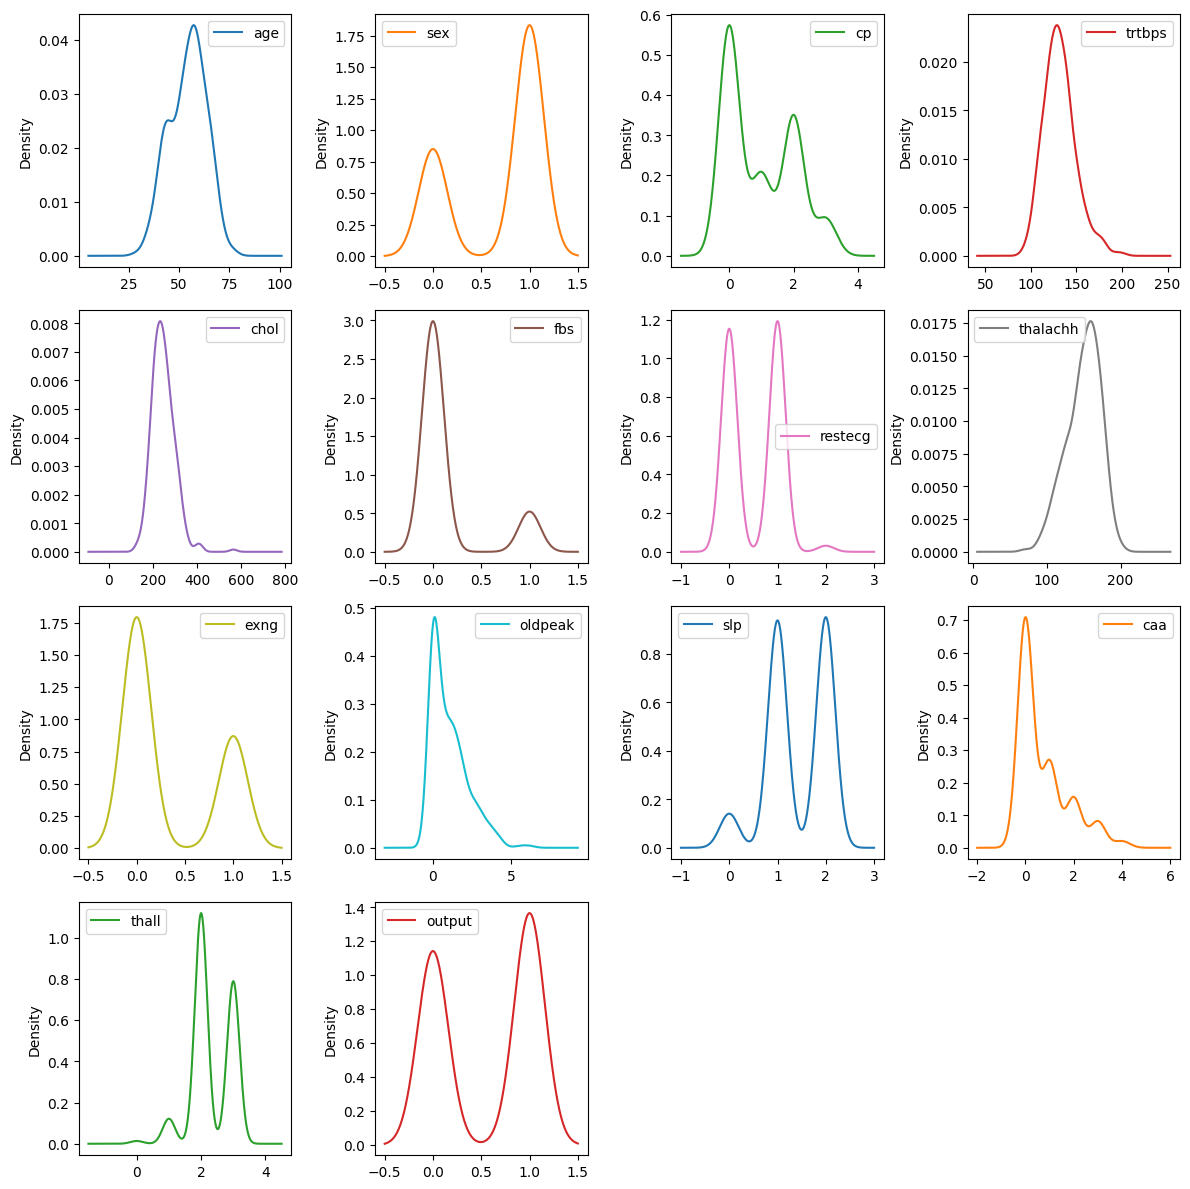

In [ ]:
df.plot(kind='density', subplots=True, layout=(4, 4), figsize=(12, 12), sharex=False)
plt.tight_layout()
plt.show()

Teniendo en cuenta que la variable objetivo "output" no presenta diferencias significativas en su distribución, no es necesario realizar balanceo del conjunto de datos.

Se generan histogramas para visualizar la distribución de los valores de cada variable.

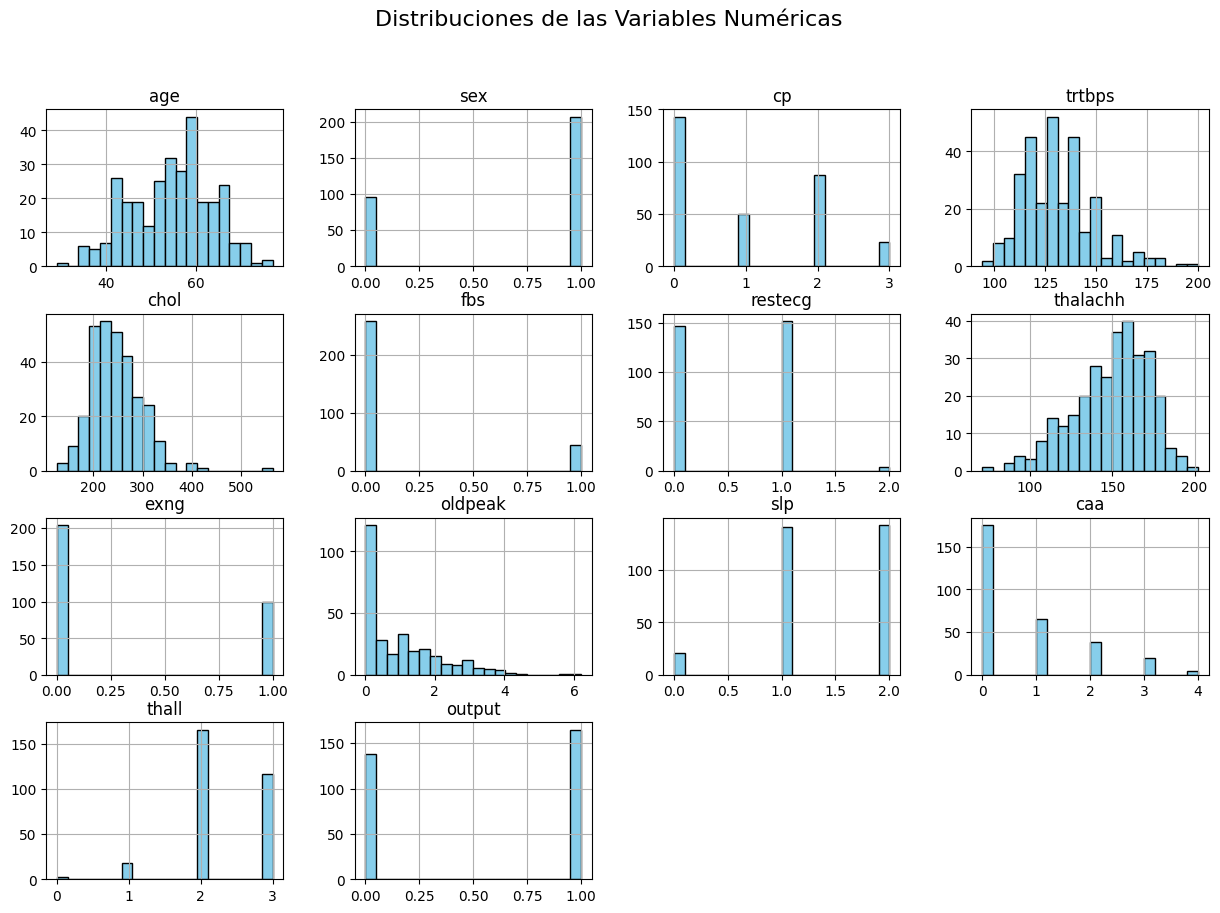

In [ ]:
# Distribución de las variables numéricas
df.hist(figsize=(15, 10), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Distribuciones de las Variables Numéricas', fontsize=16)
plt.show()


#Diagrama de cajas antes de preprocesar los datos

El siguiente diagrama se emplea para identificar los valores atipicos de cada variable.

,0
0,"Axes(0.1,0.15;0.363636x0.75)"
1,"Axes(0.536364,0.15;0.363636x0.75)"


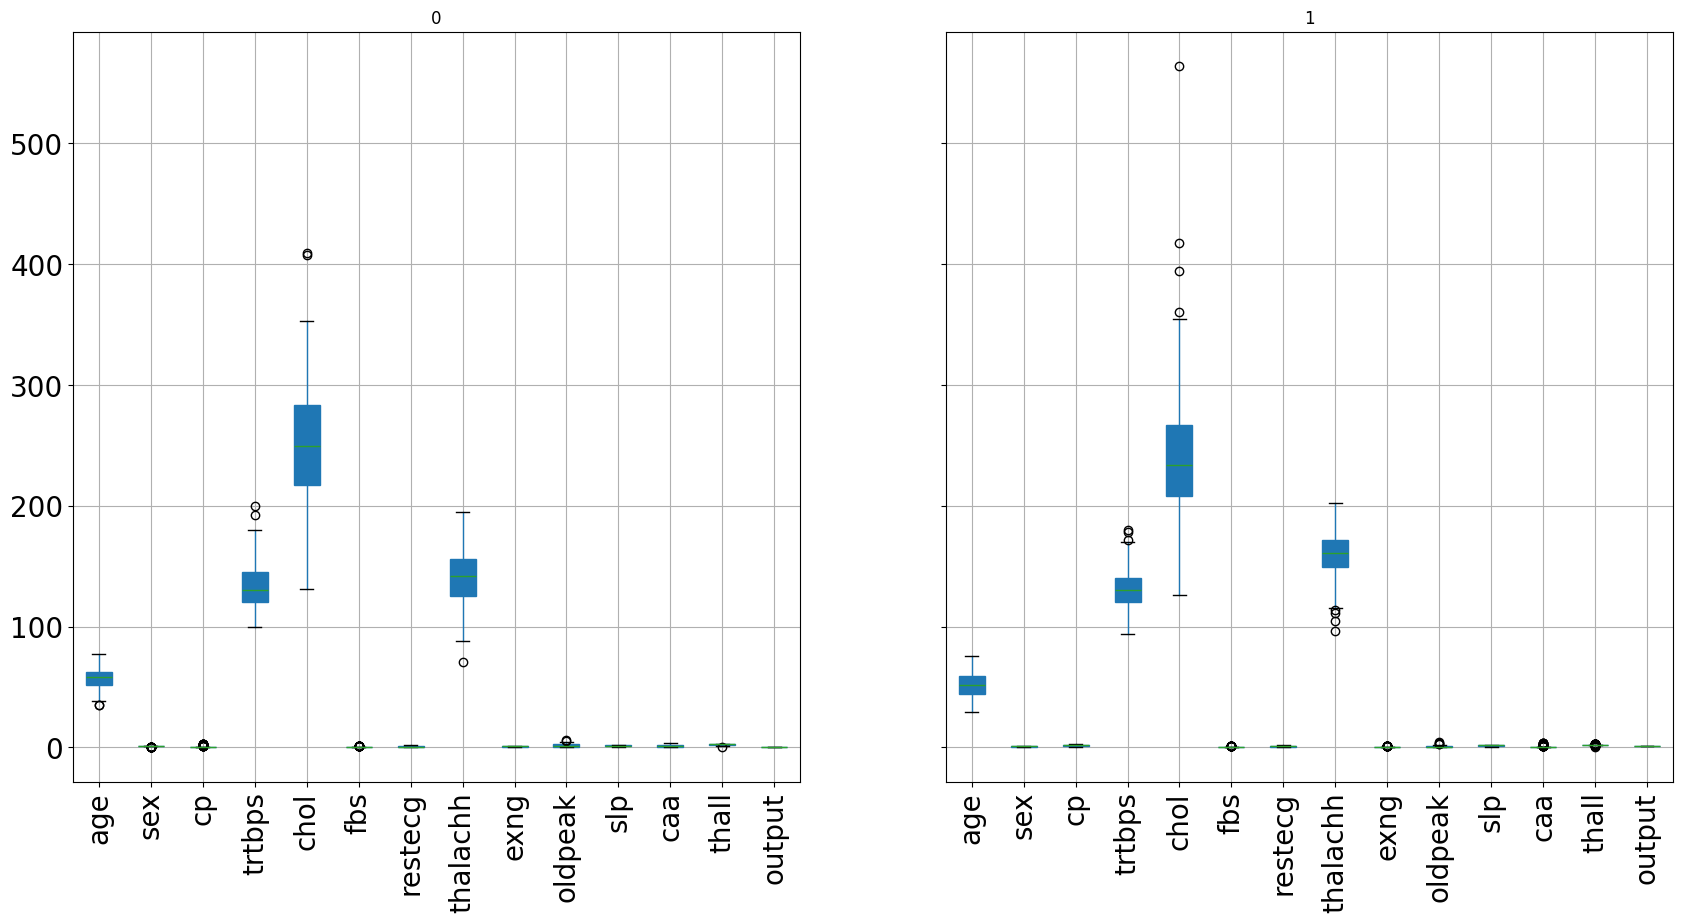

In [ ]:
df.groupby('output').boxplot(fontsize=20,rot=90,figsize=(20,10),patch_artist=True)

#Matriz de correlación

El conjunto de datos presenta la siguiente matriz de correlación

In [ ]:
corr_matrix = df.corr()
corr_matrix["output"].sort_values(ascending=False)

,output
output,1.000000
cp,0.433798
thalachh,0.421741
slp,0.345877
restecg,0.137230
fbs,-0.028046
chol,-0.085239
trtbps,-0.144931
age,-0.225439
sex,-0.280937


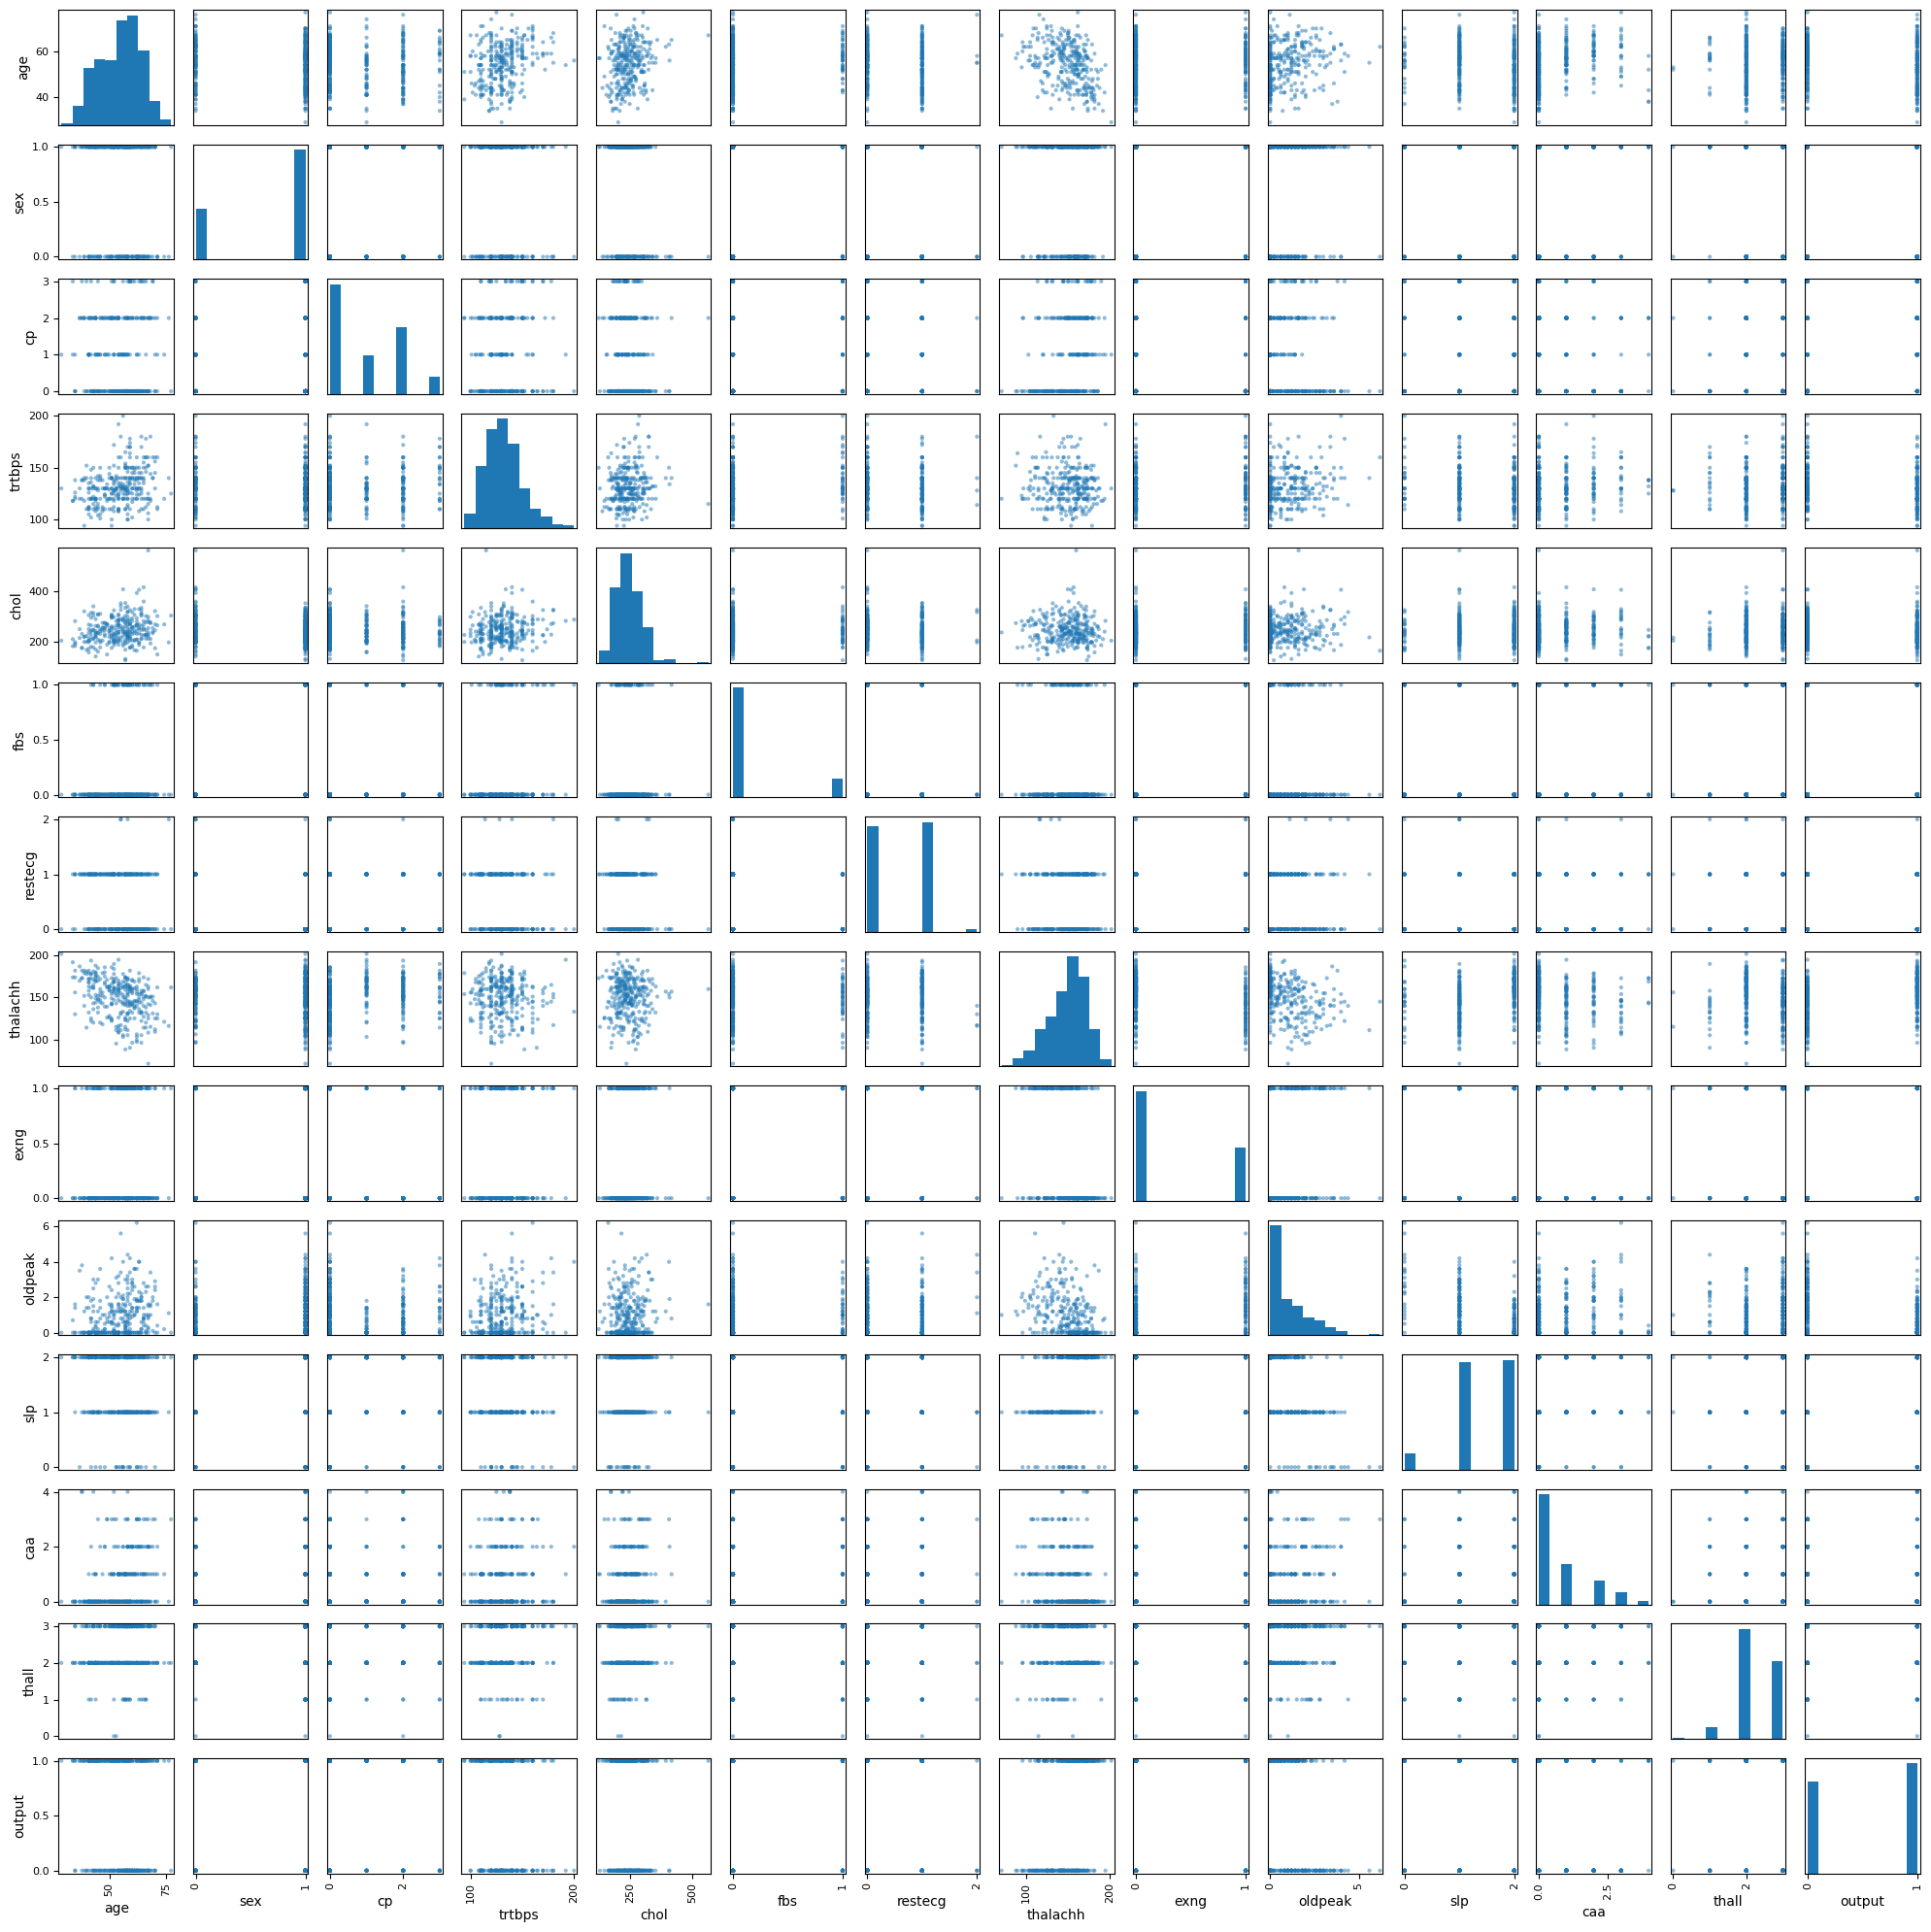

In [ ]:
pd.plotting.scatter_matrix(df,figsize=(20,20))
plt.tight_layout()
plt.show()

Mapa de calor de la matriz de correlación

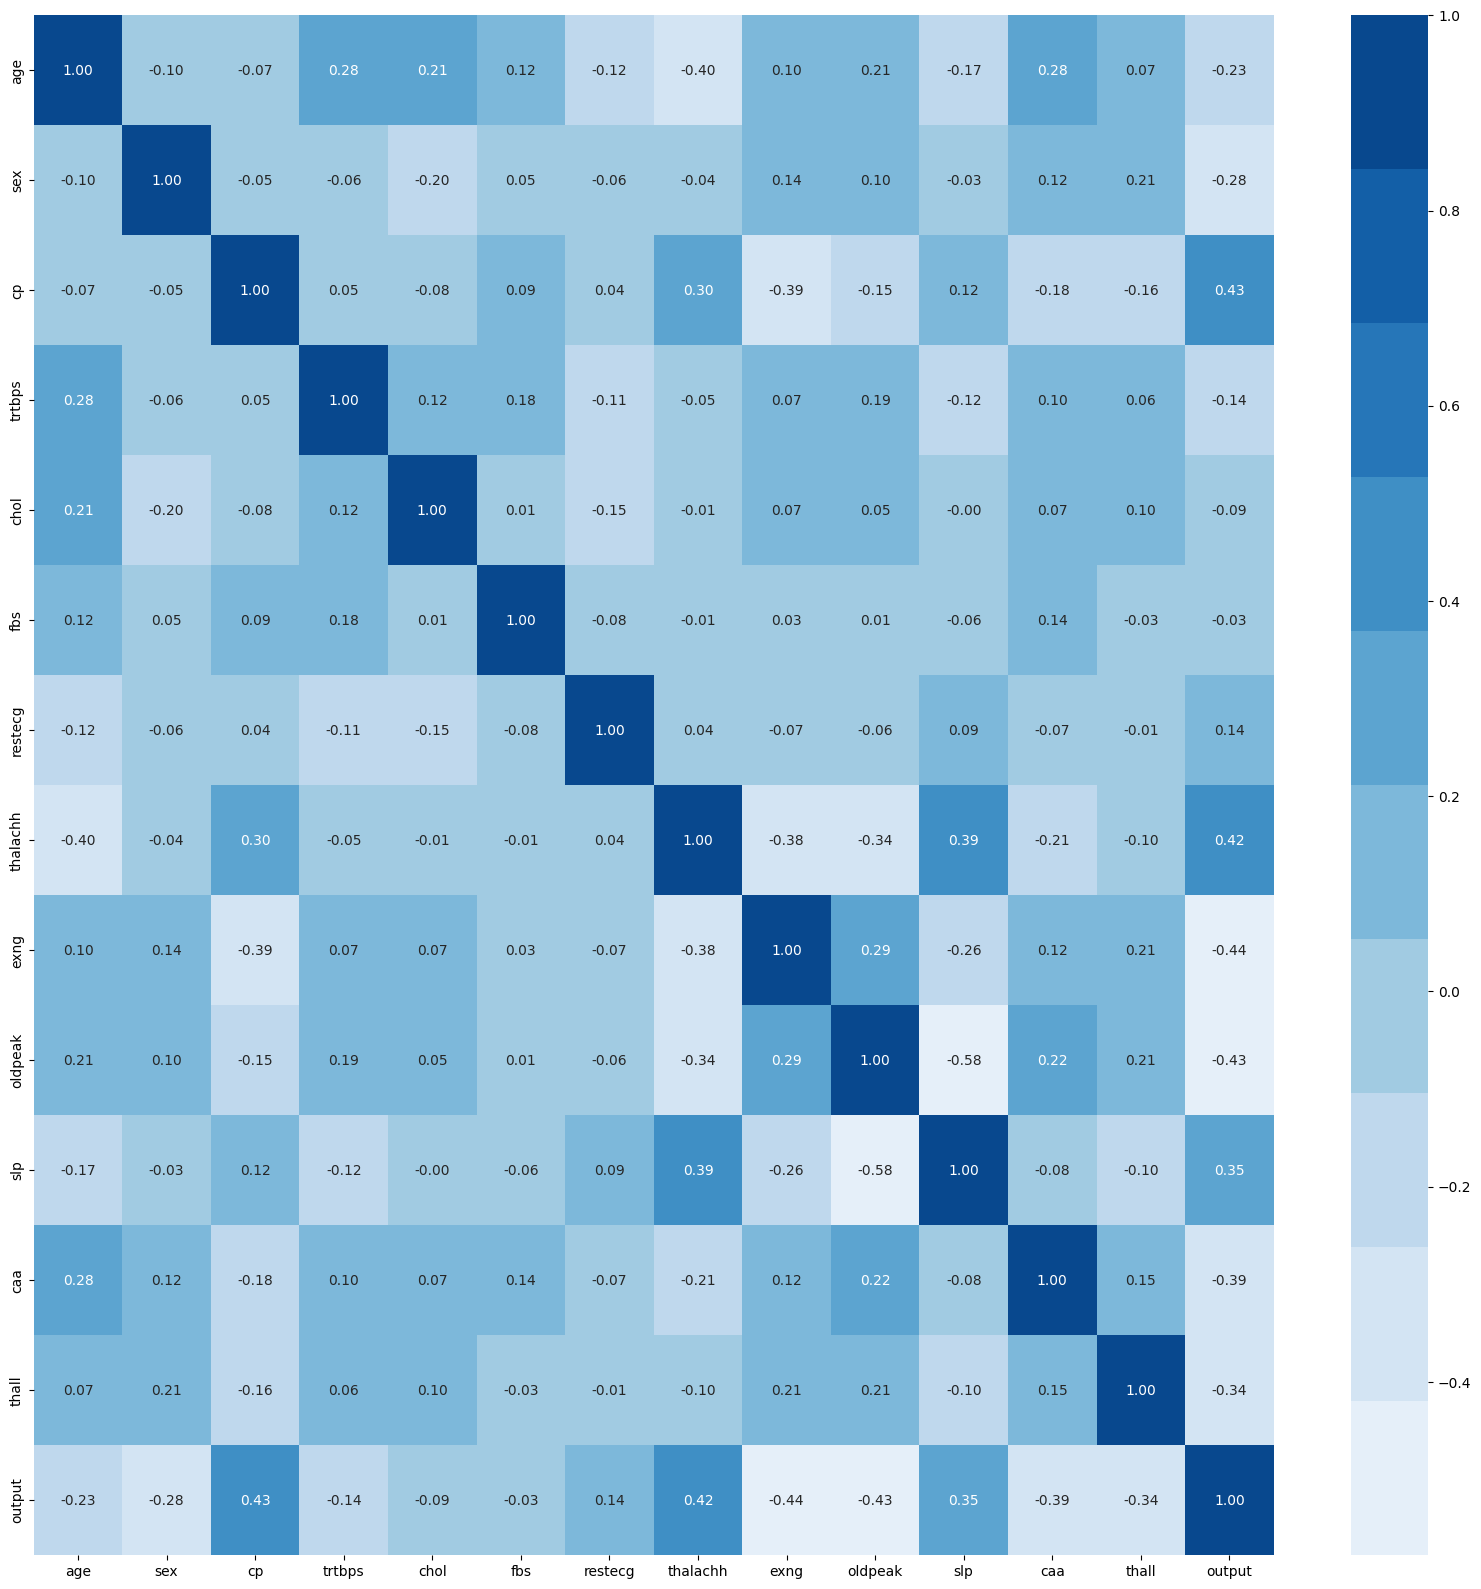

In [ ]:
# Plot figsize
fig, ax = plt.subplots(figsize=(20, 20))
# Generate Color Map
# colormap = sns.diverging_palette(220, 10, as_cmap=True)
colormap = sns.color_palette("Blues", 10)
# Generate Heat Map, allow annotations and place floats in map
sns.heatmap(corr_matrix, cmap=colormap, annot=True, fmt=".2f")
#ax.set_yticklabels(column_names);
plt.show()

#Procesamiento de los datos

Teniendo en cuenta que el dataset contiene distintas variables de tipo categorico, se procede a aplicar el metodo get_dummies, para facilitar la interpretación del modelo.

In [ ]:
# Definicion de variables categoricas
categorical_vars = ['sex', 'cp', 'fbs', 'restecg', 'exng', 'slp', 'thall']

# aplica get_dummies
df_heart = pd.get_dummies(df, columns=categorical_vars, drop_first=False)
df_heart = df_heart.astype(int)

# muestra el nuevo Dataframe
df_heart.head()


,age,trtbps,chol,thalachh,oldpeak,caa,output,sex_0,sex_1,cp_0,...,restecg_2,exng_0,exng_1,slp_0,slp_1,slp_2,thall_0,thall_1,thall_2,thall_3
0,63,145,233,150,2,0,1,0,1,0,...,0,1,0,1,0,0,0,1,0,0
1,37,130,250,187,3,0,1,0,1,0,...,0,1,0,1,0,0,0,0,1,0
2,41,130,204,172,1,0,1,1,0,0,...,0,1,0,0,0,1,0,0,1,0
3,56,120,236,178,0,0,1,0,1,0,...,0,1,0,0,0,1,0,0,1,0
4,57,120,354,163,0,0,1,1,0,1,...,0,0,1,0,0,1,0,0,1,0


In [ ]:

# Mover la columna 'output' a la última posición
output_col = df_heart.pop('output')
df_heart['output'] = output_col

# Mostrar los primeros registros del DataFrame resultante
df_heart.head()


,age,trtbps,chol,thalachh,oldpeak,caa,sex_0,sex_1,cp_0,cp_1,...,exng_0,exng_1,slp_0,slp_1,slp_2,thall_0,thall_1,thall_2,thall_3,output
0,63,145,233,150,2,0,0,1,0,0,...,1,0,1,0,0,0,1,0,0,1
1,37,130,250,187,3,0,0,1,0,0,...,1,0,1,0,0,0,0,1,0,1
2,41,130,204,172,1,0,1,0,0,1,...,1,0,0,0,1,0,0,1,0,1
3,56,120,236,178,0,0,0,1,0,1,...,1,0,0,0,1,0,0,1,0,1
4,57,120,354,163,0,0,1,0,1,0,...,0,1,0,0,1,0,0,1,0,1


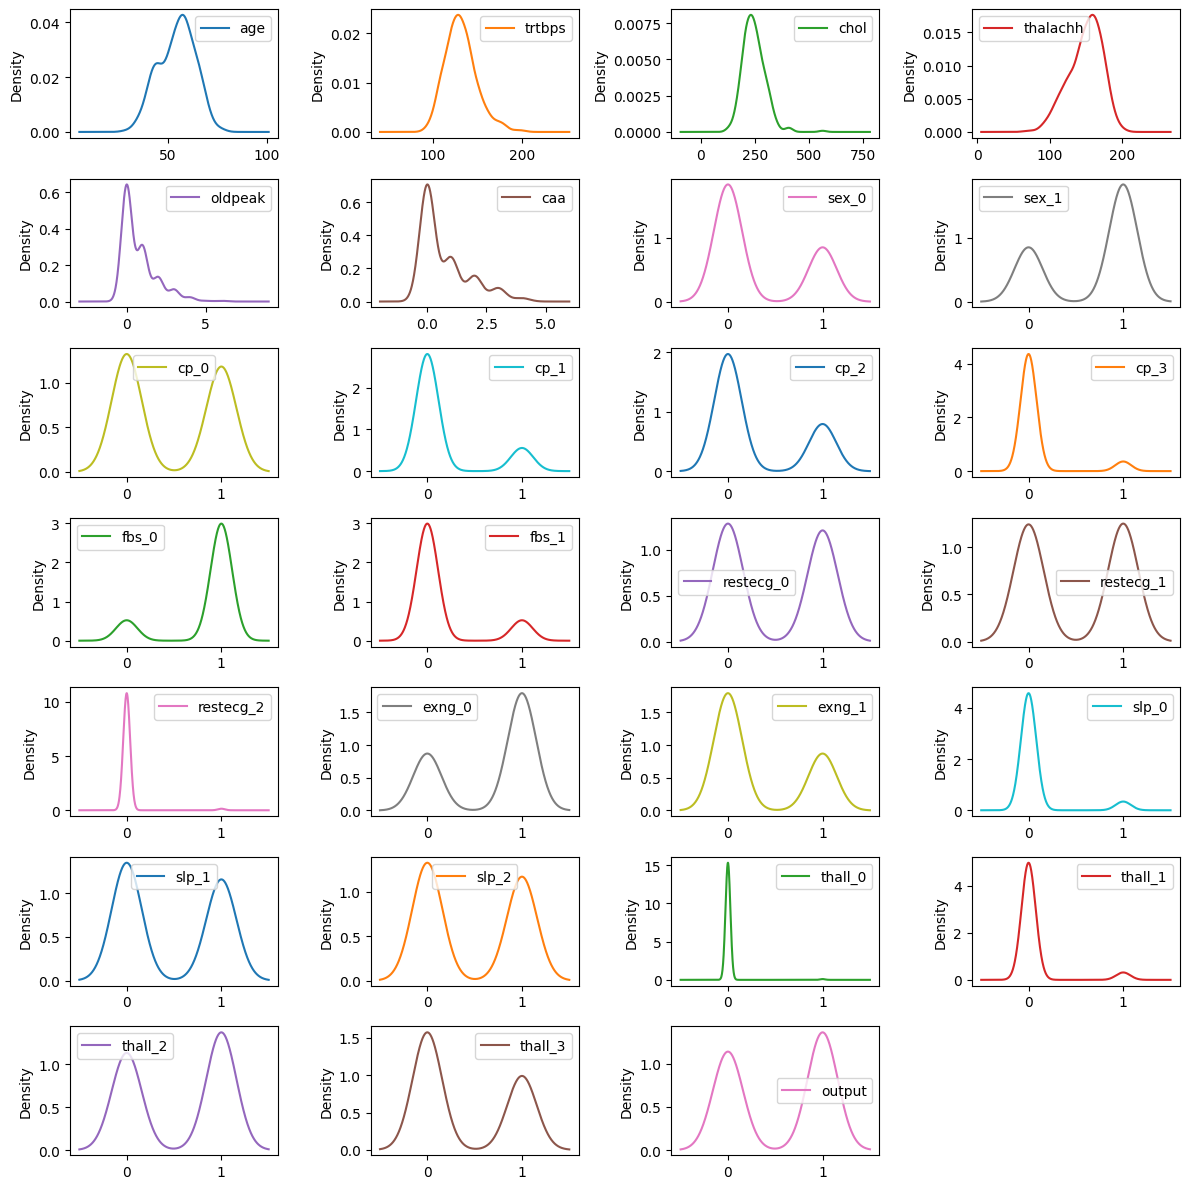

In [ ]:
df_heart.plot(kind='density', subplots=True, layout=(7, 4), figsize=(12, 12), sharex=False)
plt.tight_layout()
plt.show()

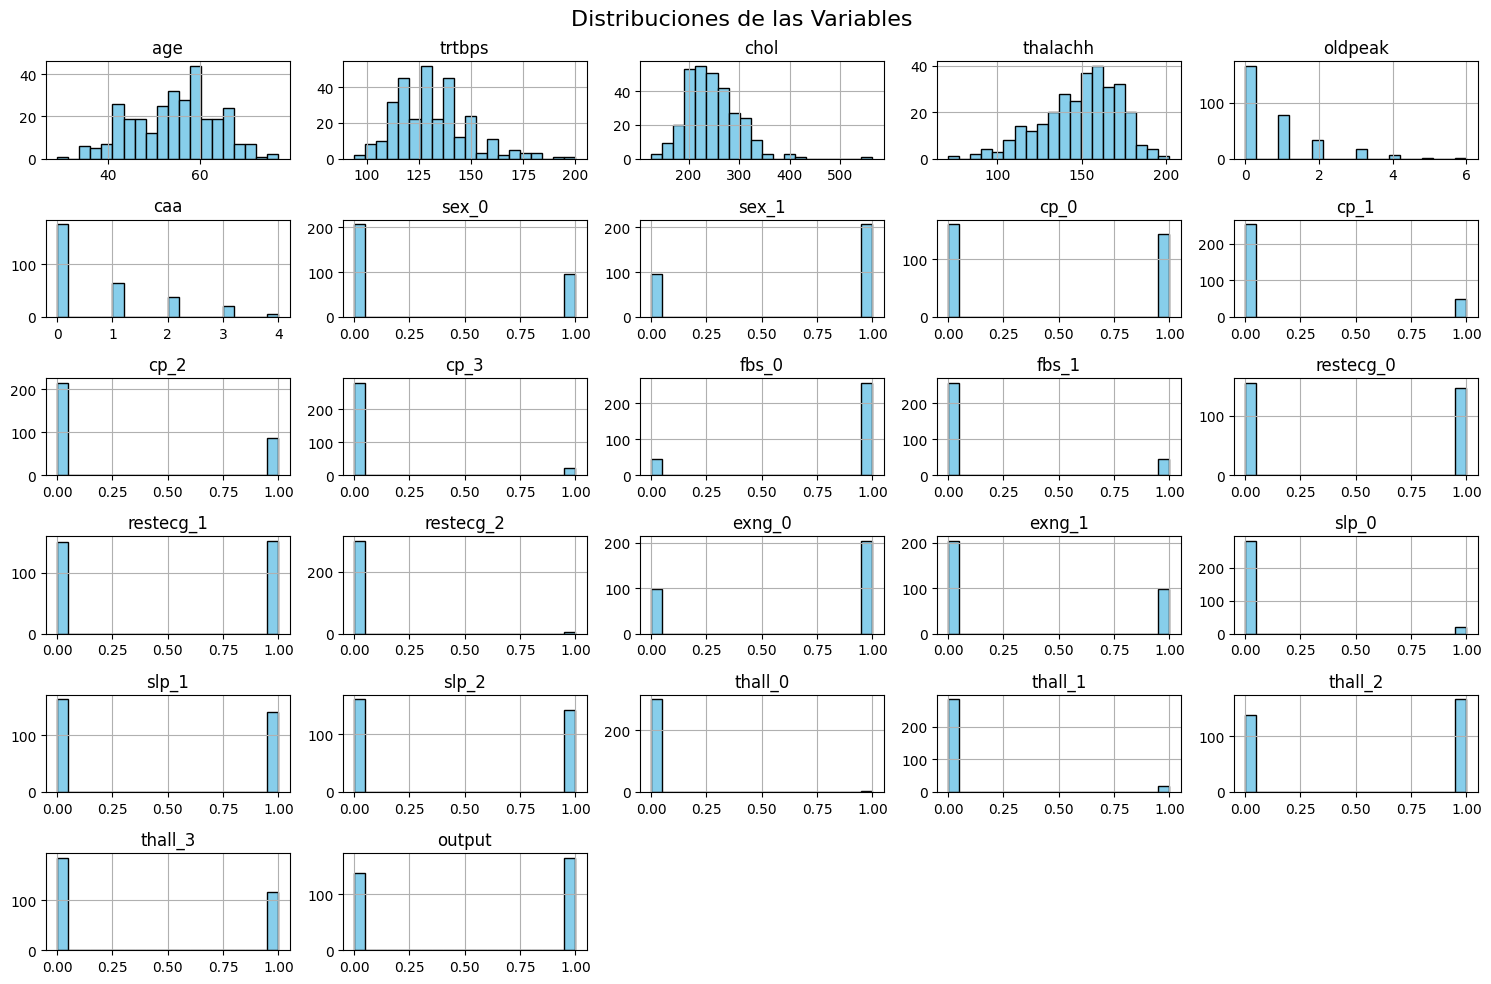

In [ ]:
# Distribución de las variables numéricas
df_heart.hist(figsize=(15, 10), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Distribuciones de las Variables ', fontsize=16)
plt.tight_layout()

plt.show()

#Matriz de correlación de datos procesados

In [ ]:
corr_matrix = df_heart.corr()
corr_matrix["output"].sort_values(ascending=False)

,output
output,1.000000
thall_2,0.527334
exng_0,0.436757
thalachh,0.421741
slp_2,0.394066
cp_2,0.316742
sex_0,0.280937
cp_1,0.245879
restecg_1,0.175322
cp_3,0.086957


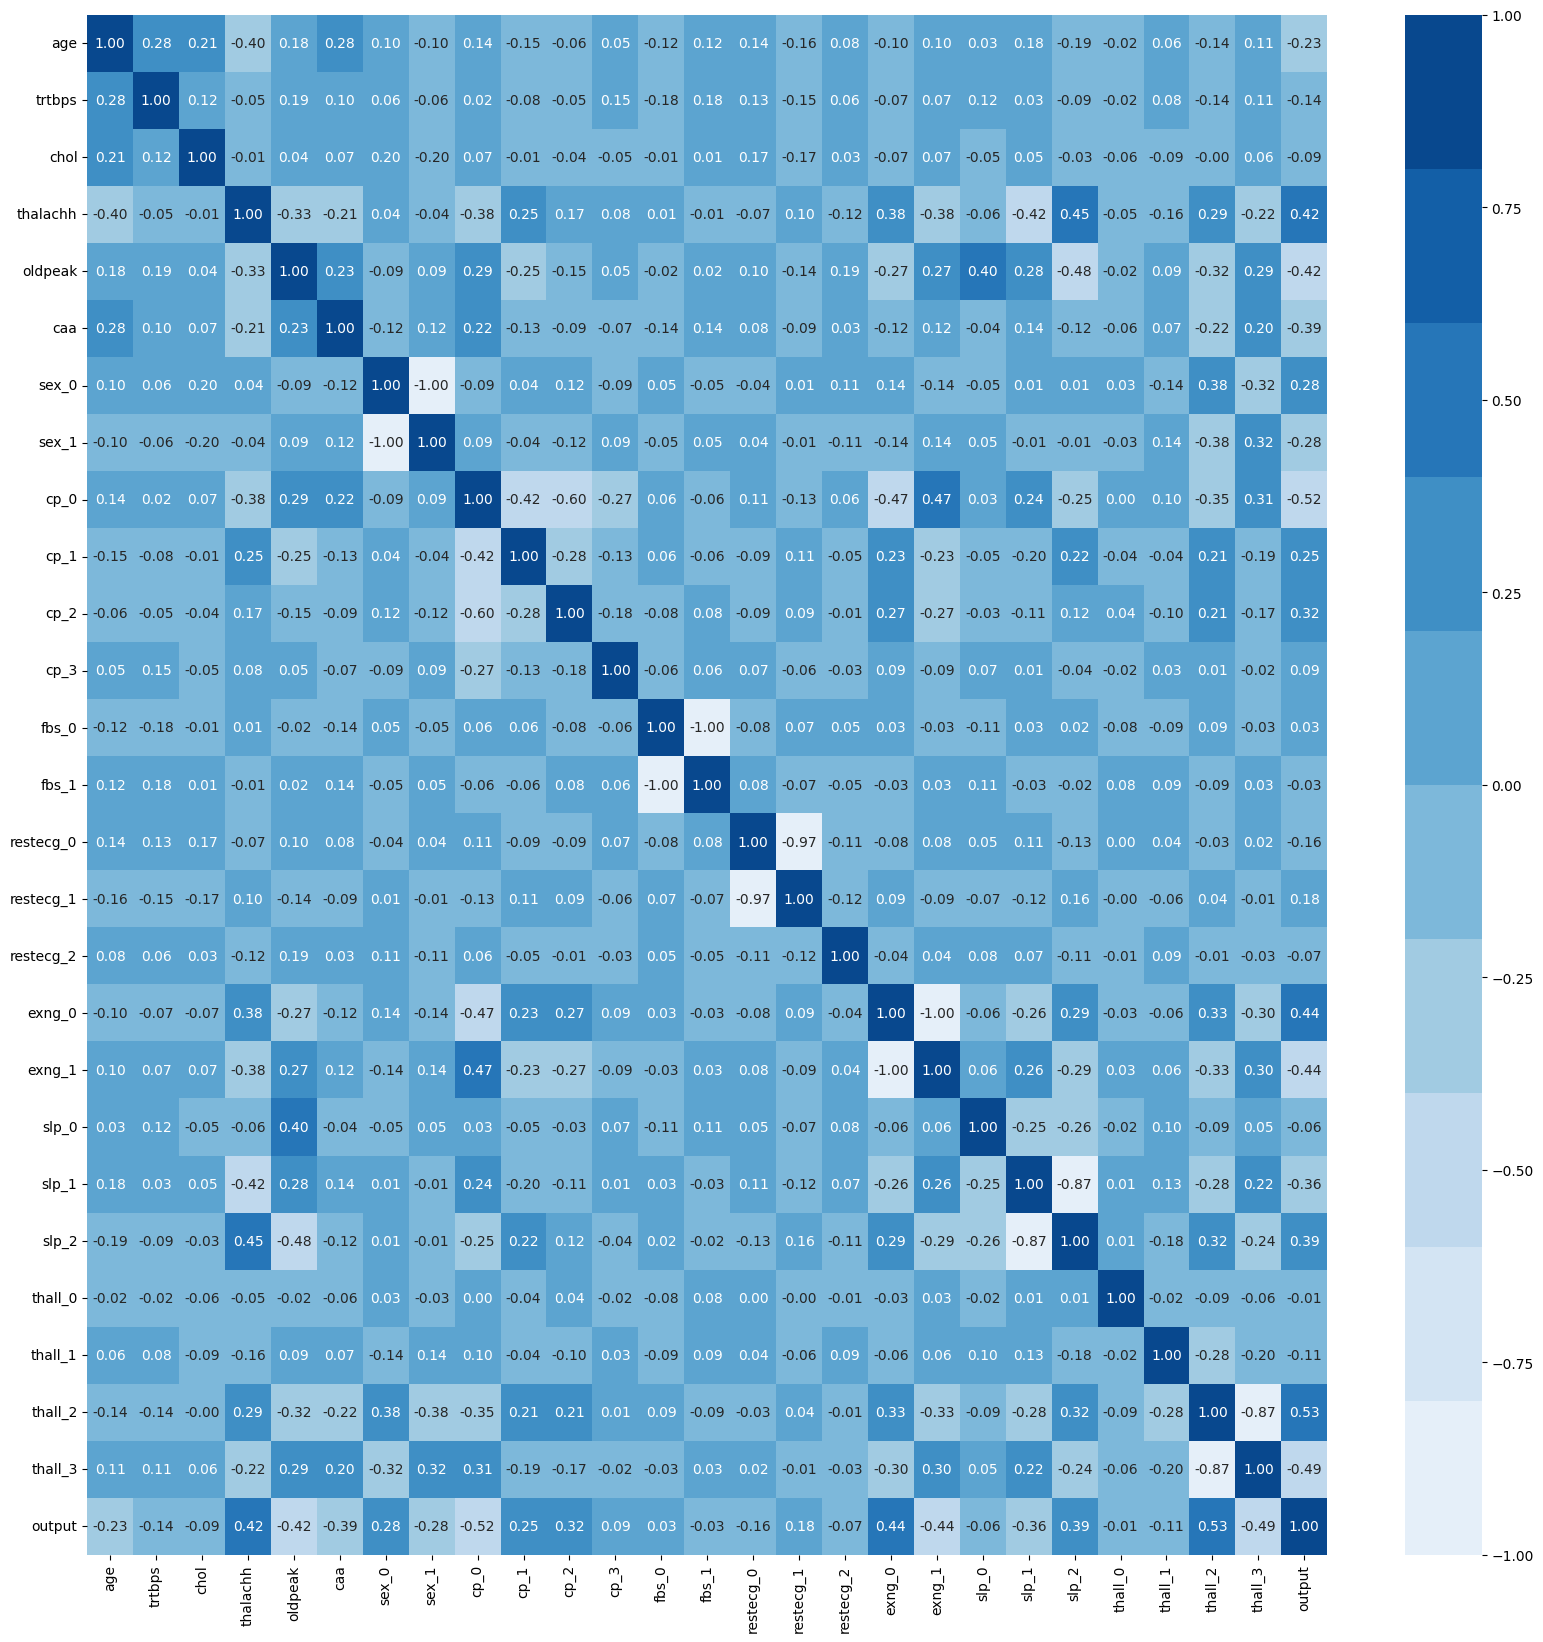

In [ ]:
# Plot figsize
fig, ax = plt.subplots(figsize=(20, 20))
# Generate Color Map
# colormap = sns.diverging_palette(220, 10, as_cmap=True)
colormap = sns.color_palette("Blues", 10)
# Generate Heat Map, allow annotations and place floats in map
sns.heatmap(corr_matrix, cmap=colormap, annot=True, fmt=".2f")
#ax.set_yticklabels(column_names);
plt.show()

#Definición de algoritmos

Teniendo en cuenta que la variable objetivo del dataframe es de tipo binario, el tipo de algoritmo a elegir debe ser de clasificación. De acuerdo a la bibliografia encontrada y expuesta de manera mas detallada en el estado del arte, se escogen los algoritmos Random Forest, CNN y

#Conjuntos de entrenamiento y pruebas

In [ ]:
#Importe de objetos
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import roc_curve, roc_auc_score, auc
import matplotlib.pyplot as plt


#Se separan las caracteristicas de la variable objetivo.

X = df_heart.drop('output', axis=1)
y = df_heart['output']


#Definción de conjunto de entrenamiento y de pruebas
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Implementación de Random Forest

In [ ]:
#Importe de objeto
from sklearn.ensemble import RandomForestClassifier
# Definición del modelo
RF_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenamiento
RF_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

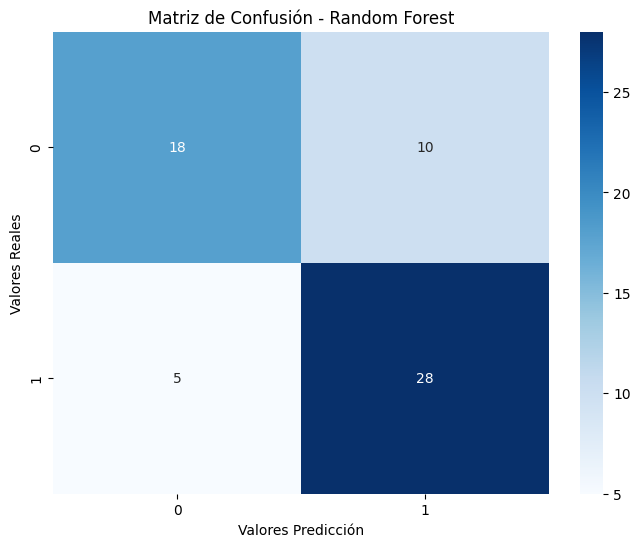


Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.64      0.71        28
           1       0.74      0.85      0.79        33

    accuracy                           0.75        61
   macro avg       0.76      0.75      0.75        61
weighted avg       0.76      0.75      0.75        61


Accuracy Score: 0.7540983606557377


In [ ]:
#Predicción
RF_pred = RF_model.predict(X_test)



# Matriz de Confusión
conf_matrix = confusion_matrix(y_test, RF_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - Random Forest")
plt.ylabel("Valores Reales")
plt.xlabel("Valores Predicción")
plt.show()


# Evaluaación
#print("Confusion Matrix:\n", confusion_matrix(y_test, RF_pred))
print("\nClassification Report:\n", classification_report(y_test, RF_pred))
print("\nAccuracy Score:", accuracy_score(y_test, RF_pred))


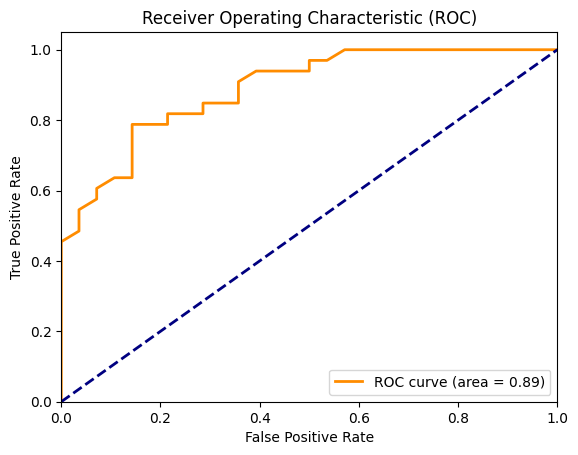

AUC: 0.89


In [ ]:
# Hacer predicciones de probabilidad sobre el conjunto de prueba
RF_pred_prob = RF_model.predict_proba(X_test)[:, 1]

# Calculo de la curva ROC
RF_fpr, RF_tpr, thresholds = roc_curve(y_test, RF_pred_prob)
RF_roc_auc = auc(RF_fpr, RF_tpr)

# figura de curva ROC
plt.figure()
plt.plot(RF_fpr, RF_tpr, color='darkorange', lw=2, label=f'ROC curve (area = {RF_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

#valor de AUC
print(f'AUC: {RF_roc_auc:.2f}')


#XGBoost

In [ ]:
import xgboost as xgb

#from sklearn.metrics import accuracy_score, classification_report

# Definición del modelo
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

# Entrenamiento
model.fit(X_train, y_train)

# Predicciones
xgb_pred = model.predict(X_test)
xgb_prob = model.predict_proba(X_test)[:, 1]
# Evaluación
accuracy = accuracy_score(y_test, xgb_pred)
report = classification_report(y_test, xgb_pred)

print(f'Accuracy: {accuracy}')
print(f'Classification Report:\n{report}')



/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [04:48:36] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.7540983606557377
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.64      0.71        28
           1       0.74      0.85      0.79        33

    accuracy                           0.75        61
   macro avg       0.76      0.75      0.75        61
weighted avg       0.76      0.75      0.75        61



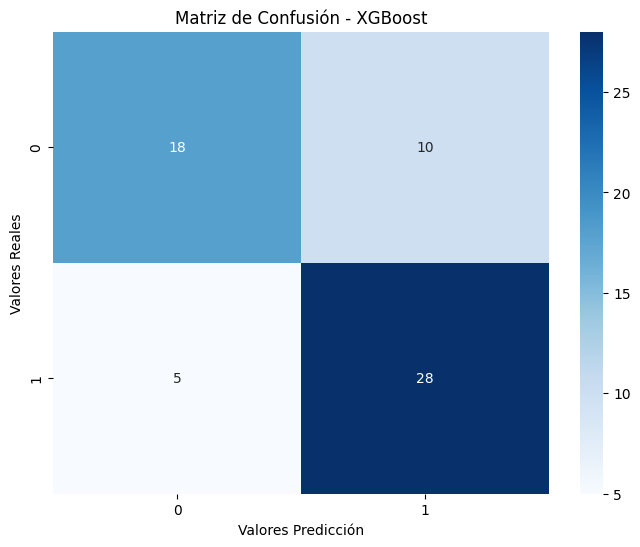

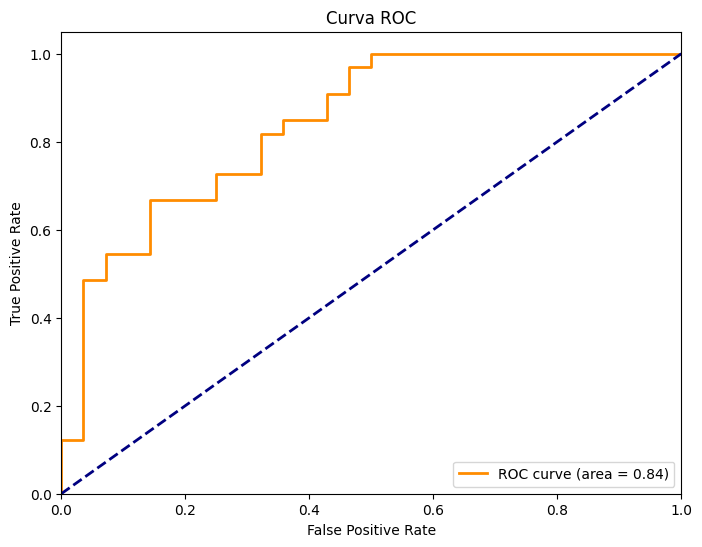

In [ ]:

# Matriz de Confusión
conf_matrix = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - XGBoost")
plt.ylabel("Valores Reales")
plt.xlabel("Valores Predicción")
plt.show()

# Curva ROC
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)
xgb_roc_auc = auc(xgb_fpr, xgb_tpr)

plt.figure(figsize=(8, 6))
plt.plot(xgb_fpr, xgb_tpr, color='darkorange', lw=2, label=f'ROC curve (area = {xgb_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()


# Implementacion de K-Nearest Neighbors


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
# Definición del modelo
knn = KNeighborsClassifier(n_neighbors=5)

# Entrenamiento
knn.fit(X_train, y_train)

# Predicciones
knn_y_pred = knn.predict(X_test)
knn_prob = knn.predict_proba(X_test)[:, 1]

# Evaluación
accuracy = accuracy_score(y_test, knn_y_pred)
report = classification_report(y_test, knn_y_pred)
print(f'Accuracy: {accuracy}')
print(f'Classification Report:\n{report}')



Accuracy: 0.5901639344262295
Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.57      0.56        28
           1       0.62      0.61      0.62        33

    accuracy                           0.59        61
   macro avg       0.59      0.59      0.59        61
weighted avg       0.59      0.59      0.59        61



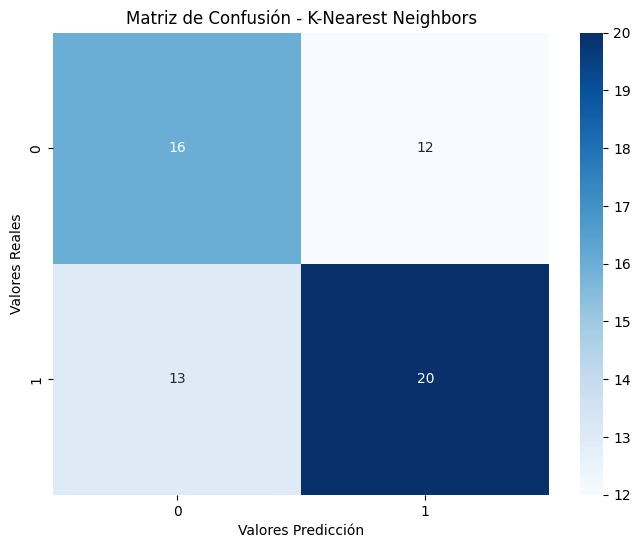

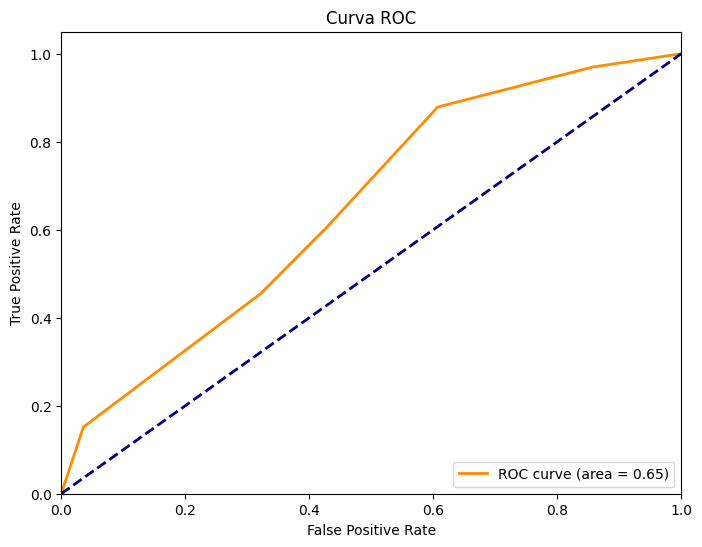

In [ ]:
# Matriz de Confusión
conf_matrix = confusion_matrix(y_test, knn_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - K-Nearest Neighbors")
plt.ylabel("Valores Reales")
plt.xlabel("Valores Predicción")
plt.show()

# Curva ROC
knn_fpr, knn_tpr, _ = roc_curve(y_test, knn_prob)
knn_roc_auc = auc(knn_fpr, knn_tpr)

plt.figure(figsize=(8, 6))
plt.plot(knn_fpr, knn_tpr, color='darkorange', lw=2, label=f'ROC curve (area = {knn_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()

#SVM (Support Vector Machines)

In [ ]:
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

In [ ]:
from google.colab import drive
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.svm import SVC
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, MaxPooling1D, Dropout

# Montar Google Drive
drive.mount('/content/drive')

# Cargar datos
df = pd.read_csv('/content/drive/MyDrive/heart.csv')


X = df.drop(columns=['output'])
y = df['output']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Definir los parámetros para GridSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}

# Realizar búsqueda de hiperparámetros
grid = GridSearchCV(SVC(probability=True), param_grid, refit=True, cv=5, scoring='roc_auc')
grid.fit(X_train_scaled, y_train)

# Mejor modelo
best_svm = grid.best_estimator_
print(f"Mejores parámetros SVM: {grid.best_params_}")

# Predicciones y evaluación
svm_y_pred = best_svm.predict(X_test_scaled)
svm_prob = best_svm.predict_proba(X_test_scaled)[:, 1]
svm_accuracy = accuracy_score(y_test, svm_y_pred)
svm_auc = roc_auc_score(y_test, svm_prob)

print(f"Optimized SVM Accuracy: {svm_accuracy}")
print(f"Optimized SVM AUC: {svm_auc}")
print("Optimized SVM Classification Report:")
print(classification_report(y_test, svm_y_pred))

Mejores parámetros SVM: {'C': 100, 'gamma': 1, 'kernel': 'linear'}
Optimized SVM Accuracy: 0.8032786885245902
Optimized SVM AUC: 0.8809523809523809
Optimized SVM Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.64      0.75        28
           1       0.76      0.94      0.84        33

    accuracy                           0.80        61
   macro avg       0.83      0.79      0.79        61
weighted avg       0.82      0.80      0.80        61



# CNN (Red Neuronal Convolucional)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, MaxPooling1D, Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Preparar datos para CNN
X_train_cnn = X_train_scaled[..., None]
X_test_cnn = X_test_scaled[..., None]

# Arquitectura mejorada de CNN
cnn = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

# Compilar el modelo
cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Callbacks para optimización de aprendizaje
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

# Entrenamiento del modelo CNN
cnn.fit(X_train_cnn, y_train, epochs=70, batch_size=32, validation_data=(X_test_cnn, y_test), callbacks=[reduce_lr], verbose=1)

# Evaluación
cnn_y_pred = (cnn.predict(X_test_cnn) > 0.5).astype("int32")
cnn_prob = cnn.predict(X_test_cnn).ravel()
cnn_accuracy = accuracy_score(y_test, cnn_y_pred)
cnn_auc = roc_auc_score(y_test, cnn_prob)

print(f"Optimized CNN Accuracy: {cnn_accuracy}")
print(f"Optimized CNN AUC: {cnn_auc}")
print("Optimized CNN Classification Report:")
print(classification_report(y_test, cnn_y_pred))

Epoch 1/70


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.5006 - loss: 1.9223 - val_accuracy: 0.5902 - val_loss: 1.7856 - learning_rate: 0.0010
Epoch 2/70
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5565 - loss: 1.7651 - val_accuracy: 0.6885 - val_loss: 1.6384 - learning_rate: 0.0010
Epoch 3/70
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5384 - loss: 1.6241 - val_accuracy: 0.6885 - val_loss: 1.5040 - learning_rate: 0.0010
Epoch 4/70
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6257 - loss: 1.5001 - val_accuracy: 0.7377 - val_loss: 1.3887 - learning_rate: 0.0010
Epoch 5/70
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5931 - loss: 1.3902 - val_accuracy: 0.7541 - val_loss: 1.2832 - learning_rate: 0.0010
Epoch 6/70
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6360 - loss: 1.2830 - val_accuracy: 0.7541 - val_loss: 1.1892 - learning_rate: 0.0010
Epoch 7/70
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6505 - loss: 1.1900 - val_accuracy: 0.7705 - val_loss: 1.

#Matriz de Confusión para CNN

In [ ]:
matrix_cnn = confusion_matrix(y_test, cnn_y_pred)

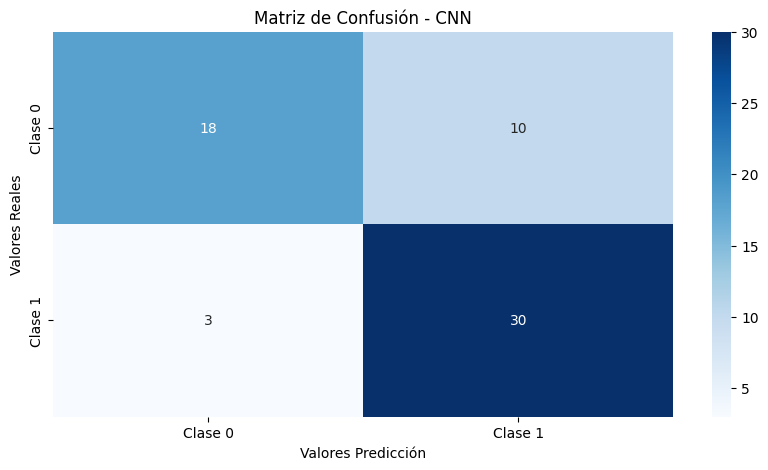

In [ ]:
# Graficar matriz de confusión para SVM
plt.figure(figsize=(10, 5))
sns.heatmap(matrix_cnn, annot=True, fmt='d', cmap='Blues', xticklabels=['Clase 0', 'Clase 1'], yticklabels=['Clase 0', 'Clase 1'])
plt.title('Matriz de Confusión - CNN')
plt.ylabel("Valores Reales")
plt.xlabel("Valores Predicción")
plt.show()

In [ ]:
svm_cm = confusion_matrix(y_test, svm_y_pred)


In [ ]:
cnn_cm = confusion_matrix(y_test, cnn_y_pred)


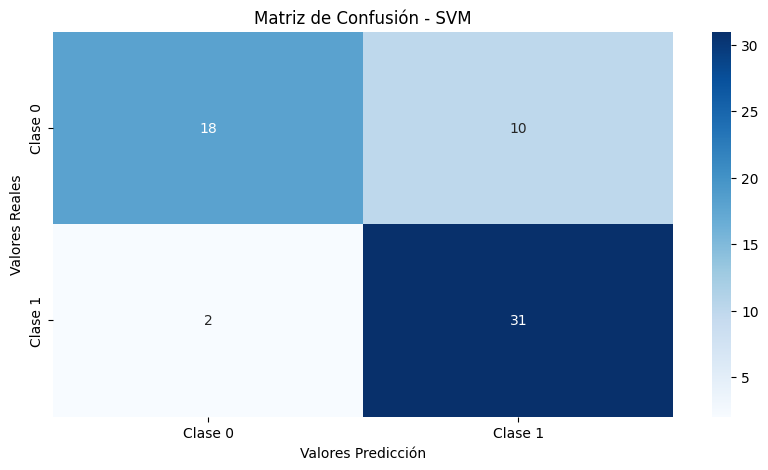

In [ ]:
svm_cm = confusion_matrix(y_test, svm_y_pred)
# Graficar matriz de confusión para SVM
plt.figure(figsize=(10, 5))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Clase 0', 'Clase 1'], yticklabels=['Clase 0', 'Clase 1'])
plt.title('Matriz de Confusión - SVM')
plt.ylabel("Valores Reales")
plt.xlabel("Valores Predicción")
plt.show()


#Grafíca Comparativa de curvas ROC

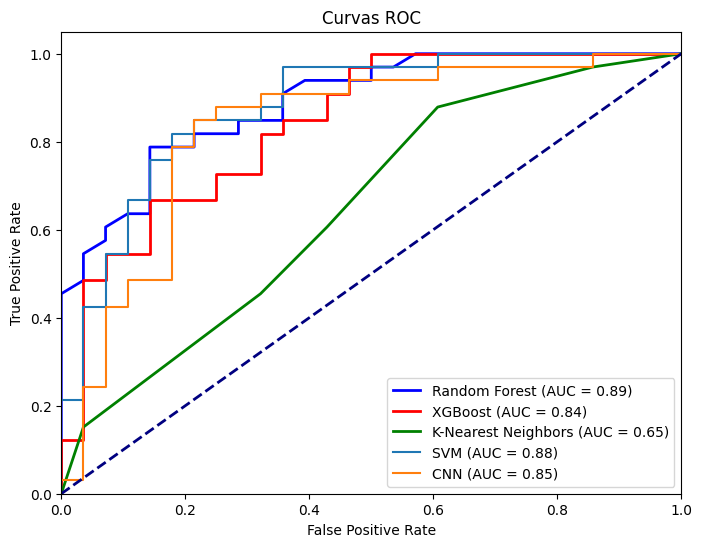

In [ ]:
# Graficar las curvas ROC
plt.figure(figsize=(8, 6))
plt.plot(RF_fpr, RF_tpr, color='blue', lw=2, label=f'Random Forest (AUC = {RF_roc_auc:.2f})')
plt.plot(xgb_fpr, xgb_tpr, color='red', lw=2, label=f'XGBoost (AUC = {xgb_roc_auc:.2f})')
plt.plot(knn_fpr, knn_tpr, color='green', lw=2, label=f'K-Nearest Neighbors (AUC = {knn_roc_auc:.2f})')
plt.plot(svm_fpr, svm_tpr, label=f'SVM (AUC = {svm_auc:.2f})', linestyle='-')
plt.plot(cnn_fpr, cnn_tpr, label=f'CNN (AUC = {cnn_auc:.2f})', linestyle='-')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC')
plt.legend(loc="lower right")
plt.show()



In [ ]:
!jupyter nbconvert --to pdf "/content/drive/MyDrive/Colab Notebooks/Prediccion_infarto.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/Prediccion_infarto.ipynb to pdf
[NbConvertApp] ERROR | Error while converting '/content/drive/MyDrive/Colab Notebooks/Prediccion_infarto.ipynb'
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/nbconvert/nbconvertapp.py", line 487, in export_single_notebook
    output, resources = self.exporter.from_filename(
  File "/usr/local/lib/python3.10/dist-packages/nbconvert/exporters/templateexporter.py", line 386, in from_filename
    return super().from_filename(filename, resources, **kw)  # type:ignore[return-value]
  File "/usr/local/lib/python3.10/dist-packages/nbconvert/exporters/exporter.py", line 201, in from_filename
    return self.from_file(f, resources=resources, **kw)
  File "/usr/local/lib/python3.10/dist-packages/nbconvert/exporters/templateexporter.py", line 392, in from_file
    return super().from_file(file_stream, resources, **kw)  # type:ignore[return-value]
  File "/u